<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_Todo_conLags_PM25_Alfaro_Badillo_Cruz_Perez_Rupit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, TweedieRegressor, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

## 1. Lectura, exploración y procesamiento

In [2]:
# Reading
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.sample(5)  # Revisar el tipos de datos y columnas presentes

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,WIND_SPEED,SNOW,RAIN
24531,24532,2012,10,19,3,87.0,4,5.0,1018.0,NW,2.68,0,0
8807,8808,2011,1,2,23,67.0,-15,-6.0,1034.0,cv,2.67,0,0
25510,25511,2012,11,28,22,36.0,-11,-3.0,1024.0,NW,3.58,0,0
32443,32444,2013,9,13,19,186.0,18,21.0,1004.0,cv,0.89,0,0
1621,1622,2010,3,9,13,20.0,-16,-1.0,1034.0,NW,127.83,0,0


In [3]:
# Cambiar fecha a float para los modelos
# Desestacionalizar las fechas

columnas_fecha = {
    'YEAR': 'year',
    'MONTH': 'month',
    'DAY': 'day',
    'HOUR': 'hour'
}
df['date'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']].rename(columns=columnas_fecha))
df = df.drop(columns=['YEAR', 'MONTH', 'DAY', 'HOUR'])

# Hora (0-23) y el mes (1-12)
df['hora'] = df['date'].dt.hour
df['mes'] = df['date'].dt.month

# transformación a senos y cosenos)
# Para las horas (ciclo de 24 horas)
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

# Para los meses (ciclo de 12 meses)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

# Borrar todas las columnas que no necesitamos
df = df.drop(columns=['date', 'hora', 'mes'])
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   PM25            41757 non-null  float64
 2   DEWPOINT        43824 non-null  int64  
 3   TEMP            43824 non-null  float64
 4   PRESION         43824 non-null  float64
 5   WIND_DIRECTION  43824 non-null  str    
 6   WIND_SPEED      43824 non-null  float64
 7   SNOW            43824 non-null  int64  
 8   RAIN            43824 non-null  int64  
 9   hora_sin        43824 non-null  float64
 10  hora_cos        43824 non-null  float64
 11  mes_sin         43824 non-null  float64
 12  mes_cos         43824 non-null  float64
dtypes: float64(8), int64(4), str(1)
memory usage: 4.3 MB


None

In [4]:
# Cleaning and Lags

# Lags del Target (PM2.5)
df['PM25_lag1'] = df['PM25'].shift(1)
df['PM25_lag2'] = df['PM25'].shift(2)
df['PM25_lag24'] = df['PM25'].shift(24) # El ciclo de ayer a la misma hora

# Lags inmediatos del clima (Pasado reciente)
variables_clima = ['DEWPOINT', 'TEMP', 'PRESION', 'WIND_SPEED', 'RAIN', 'SNOW']

for var in variables_clima:
    df[f'{var}_lag1'] = df[var].shift(1)
    df[f'{var}_lag2'] = df[var].shift(2)

# El Efecto Acumulado (Ventanas Móviles / Rolling Windows)
# Calculamos el promedio de las últimas 6 horas para capturar la tendencia sostenida
for var in variables_clima:
    # rolling(window=6) agrupa las últimas 6 filas, .mean() saca el promedio
    df[f'{var}_media_6h'] = df[var].rolling(window=6).mean()

# Si creen que algo más largo importa, pueden hacer una de 12 horas
for var in variables_clima:
    df[f'{var}_media_12h'] = df[var].rolling(window=12).mean()

# Limpieza final
# Como el lag 24 y la ventana de 12 horas necesitan datos del pasado,
# las primeras 24 filas de todo el dataframe quedarán con NaN. Las borramos.
df_final = df.dropna().reset_index(drop=True)
# Por si quiero quedarme con los NAs de PM2.5 para imputarlos
# Advertencia: pero no tiene mucho sentido porque se trata de la variable dependiente :/
# df_final = df.copy()
display(df_final.info())

<class 'pandas.DataFrame'>
RangeIndex: 40390 entries, 0 to 40389
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NO                    40390 non-null  int64  
 1   PM25                  40390 non-null  float64
 2   DEWPOINT              40390 non-null  int64  
 3   TEMP                  40390 non-null  float64
 4   PRESION               40390 non-null  float64
 5   WIND_DIRECTION        40390 non-null  str    
 6   WIND_SPEED            40390 non-null  float64
 7   SNOW                  40390 non-null  int64  
 8   RAIN                  40390 non-null  int64  
 9   hora_sin              40390 non-null  float64
 10  hora_cos              40390 non-null  float64
 11  mes_sin               40390 non-null  float64
 12  mes_cos               40390 non-null  float64
 13  PM25_lag1             40390 non-null  float64
 14  PM25_lag2             40390 non-null  float64
 15  PM25_lag24            40390 no

None

In [9]:
# Preprocesamiento: Escalado e Imputación por medio de Pipelines

# Pipeline para Números: Primero imputa con la mediana (aunque no hay nada que imputar), luego escala.
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para Texto: Codificación, OneHotEncoding.
# handle_unknown='ignore' evita que el modelo falle si en el futuro aparece una dirección de viento nueva.
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# make_column_selector, lo que hace: busca automáticamente las columnas según su tipo
preprocesamiento = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, make_column_selector(dtype_include=['float64', 'int64'])),
    ('cat', categorical_pipeline, make_column_selector(dtype_include=['object', 'category']))
], remainder='passthrough') # 'passthrough' por si hay alguna columna que no queramos tocar


# Separamos tus datos respetando el tiempo (Data Split)
corte = int(len(df_final) * 0.8)
X_train = df_final.iloc[:corte].drop(columns=['PM25'])
y_train = df_final.iloc[:corte]['PM25']

X_test = df_final.iloc[corte:].drop(columns=['PM25'])
y_test = df_final.iloc[corte:]['PM25']

pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento),
    ('modelo', LinearRegression())
])

# ENTRENAR EL PIPELINE
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['NO','DEWPOINT','TEMP',...,'WIND_SPEED_media_12h','RAIN_media_12h', 'SNOW_media_12h']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

## 2. Modelos Base y Regularización

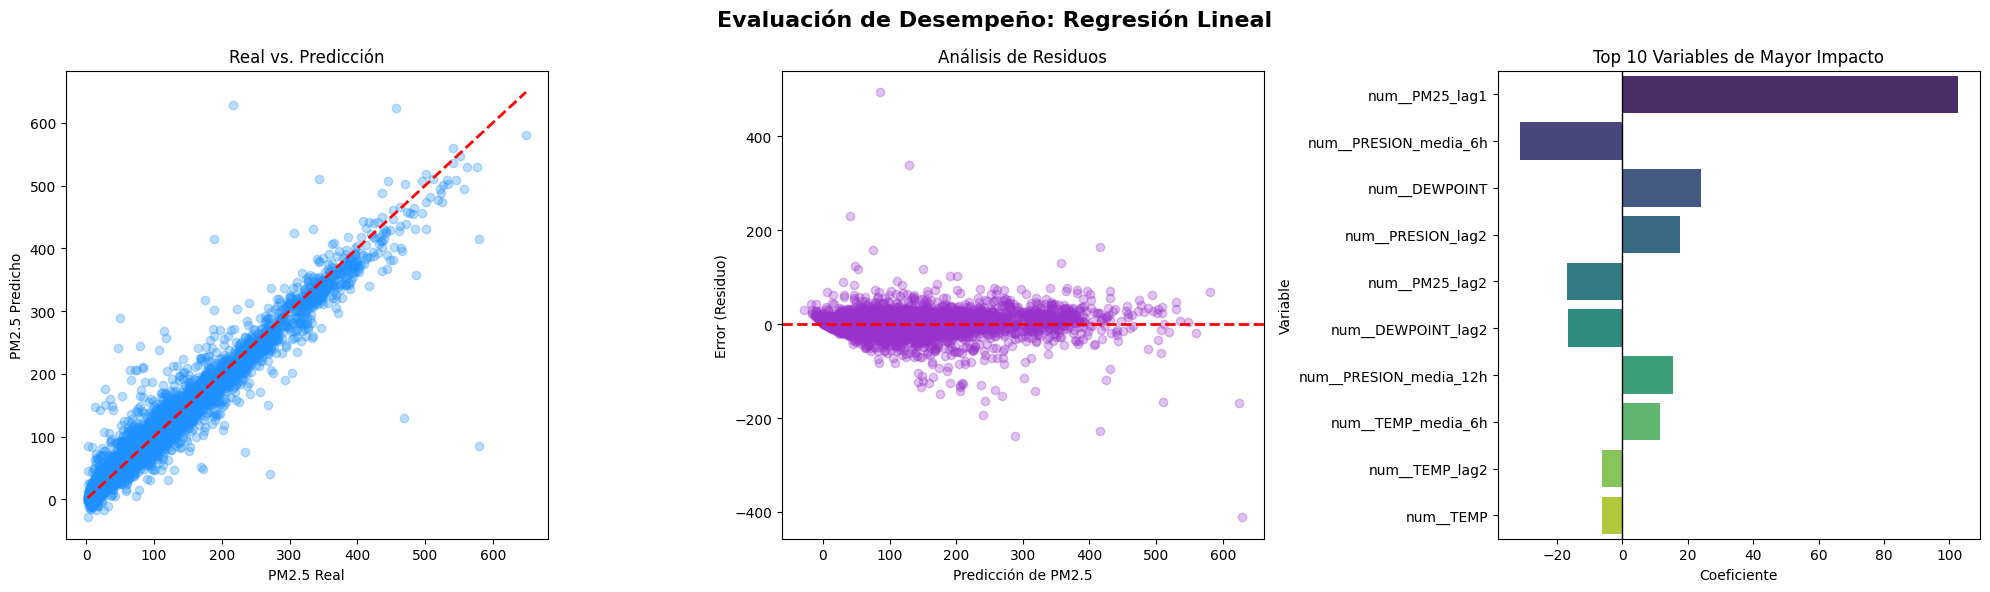

====== Métricas ======
RMSE: 20.17
MAE: 11.32
R² Score: 0.951


In [6]:
# Preparando la visualización de los modelos

def evaluar_modelo_lineal(pipeline, X_test, y_test, nombre_modelo):
    """
    Función que genera los 3 gráficos estándar de evaluación
    para cualquier modelo lineal dentro de un Pipeline.
    """
    # Hacemos las predicciones y calculamos los errores (residuos)
    predicciones = pipeline.predict(X_test)
    residuos = y_test - predicciones

    # Extraemos las entrañas del modelo (Coeficientes y Nombres)
    # pipeline[-1] accede a la última cajita (el algoritmo)
    # pipeline['prep'] accede a la primera cajita (el procesador de datos)
    modelo_puro = pipeline[-1]
    nombres_variables = pipeline['preprocesamiento'].get_feature_names_out()

    # Armamos la tabla y sacamos el Top 10 absoluto
    df_coef = pd.DataFrame({'Variable': nombres_variables, 'Coeficiente': modelo_puro.coef_})
    df_coef['Importancia_Abs'] = df_coef['Coeficiente'].abs()
    top_10 = df_coef.sort_values(by='Importancia_Abs', ascending=False).head(10)

    # Para crear los graficos
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Evaluación de Desempeño: {nombre_modelo}', fontsize=16, fontweight='bold')

    # Gráfica A: Real vs Predicho
    axes[0].scatter(y_test, predicciones, alpha=0.3, color='dodgerblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[0].set_title('Real vs. Predicción')
    axes[0].set_xlabel('PM2.5 Real')
    axes[0].set_ylabel('PM2.5 Predicho')

    # Gráfica B: Residuos
    axes[1].scatter(predicciones, residuos, alpha=0.3, color='darkorchid')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Análisis de Residuos')
    axes[1].set_xlabel('Predicción de PM2.5')
    axes[1].set_ylabel('Error (Residuo)')

    # Gráfica C: Top 10 Coeficientes
    sns.barplot(
        x='Coeficiente',
        y='Variable',
        data=top_10,
        ax=axes[2],
        hue='Variable',
        palette='viridis',
        legend=False
    )
    axes[2].set_title('Top 10 Variables de Mayor Impacto')
    axes[2].axvline(x=0, color='black', linestyle='-', linewidth=1)

    plt.tight_layout()
    plt.show()

# Métricas
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print("====== Métricas ======")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.3f}")


# Evaluar
evaluar_modelo_lineal(pipeline, X_test, y_test, "Regresión Lineal")

In [7]:
# Codigo para calcular el error (MSE, MAE, R²)
def calculo_errores(y, prediccion):
    """
    Función que genera los errores MSE, MAE, y R² para cualquiero modelo
    """
    mse = np.sqrt(mean_squared_error(y, prediccion))
    mae = mean_absolute_error(y, prediccion)
    r2 = r2_score(y, prediccion)
    return [mse, mae, r2]


In [8]:
# Lasso

# ahora unimos el preprocesador con Lasso
modelo_final_lasso = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_lasso', LassoCV(cv=5, random_state=42, max_iter=10000)) # Idealmente con TimeSeriesSplit
])

# Entrenamos
print("Entrenado Lasso (tarda un poco)")
modelo_final_lasso.fit(X_train, y_train)

# Evaluamos
evaluar_modelo_lineal(modelo_final_lasso, X_test, y_test, "Lasso (Regularización L1)")

# Prediccion
predicciones_lasso = modelo_final_lasso.predict(X_test)

# Medición de errores
error_lasso = calculo_errores(y_test, predicciones_lasso)

print("====== Lasso ======")
print(f"RMSE: {error_lasso[0]}")
print(f"MAE: {error_lasso[1]}")
print(f"R² Score: {error_lasso[2]}")

NameError: name 'preprocessor' is not defined

In [ ]:
# Ridge
modelo_final_ridge = Pipeline([
    ('preprocesamiento', preprocessor), ('modelo_ridge', RidgeCV(cv=5))
])

# Entrenamiento
print("Entrenando Ridge")
modelo_final_ridge.fit(X_train, y_train)

# Evaluamos Ridge
evaluar_modelo_lineal(modelo_final_ridge, X_test, y_test, "Ridge (Regularización L2)")

# Predicciónk
predicciones_ridge = modelo_final_ridge.predict(X_test)

# Medición de errores
error_ridge = calculo_errores(y_test, predicciones_ridge)

print("\n====== Ridge ======")
print(f"RMSE: {error_ridge[0]}")
print(f"MAE: {error_ridge[1]}")
print(f"R² Score: {error_ridge[2]}")

In [ ]:
# GLM
glm_normal = LinearRegression()

modelo_final_glm = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_glm_normal', glm_normal)
])

# Entrenamiento
print("Entrenando GLM")
modelo_final_glm.fit(X_train, y_train)

# Evaluamos el GLM
evaluar_modelo_lineal(modelo_final_glm, X_test, y_test, "GLM (Regresión Base)")

# Prediccion
predicciones_glm = modelo_final_glm.predict(X_test)

# Medición de error
error_glm = calculo_errores(y_test, predicciones_glm)

print("\n====== GLM ======")
print(f"RMSE: {error_glm[0]}")
print(f"MAE: {error_glm[1]}")
print(f"R² Score: {error_glm[2]}")

In [ ]:
# Entramos al pipeline y extraemos el modelo entrenado de la última posición [-1]
lasso_entrenado = modelo_final_lasso[-1]
ridge_entrenado = modelo_final_ridge[-1]
glm_entrenado   = modelo_final_glm[-1]

# Extraemos los nombres de las variables que salieron del preprocesamiento
# (Nota: OneHotEncoder crea nombres nuevos para las categorías, así los recuperamos)
nombres_features = modelo_final_lasso['preprocesamiento'].get_feature_names_out()

# Creamos el DataFrame de coeficientes
df_coeficientes = pd.DataFrame({
    'Variable': nombres_features,
    'Coef_GLM_Base': glm_entrenado.coef_,
    'Coef_Lasso': lasso_entrenado.coef_,
    'Coef_Ridge': ridge_entrenado.coef_
})

# Agregamos una columna con el valor absoluto de Lasso para ordenar por importancia
df_coeficientes['Importancia'] = df_coeficientes['Coef_Lasso'].abs()
df_coeficientes_ordenados = df_coeficientes.sort_values(by='Importancia', ascending=False).drop(columns=['Importancia'])

print("== Coeficientes de los modelos ==")
display(df_coeficientes_ordenados)

In [ ]:
# Analisis de Correlaciones

# Unimos tu guía de estudio (X_train y y_train) temporalmente
datos_entrenamiento = pd.concat([X_train, y_train], axis=1)

# numeric_only=True ignora la columna de texto (viento) automáticamente
correlaciones_pm25 = datos_entrenamiento.corr(numeric_only=True)['PM25'].drop('PM25')

# Ordenamos TODAS las variables (sin recortar nada)
correlaciones_ordenadas = correlaciones_pm25.sort_values(ascending=True)

plt.figure(figsize=(6, 7))

sns.barplot(
    x=correlaciones_ordenadas.values,
    y=correlaciones_ordenadas.index,
    hue=correlaciones_ordenadas.index, # Asignamos 'y' a 'hue' como pide la advertencia
    palette="coolwarm",
    legend=False                       # Apagamos la leyenda automática
)

plt.title('Correlación de TODAS las variables con PM2.5 (Set de Entrenamiento)', fontsize=16)
plt.xlabel('Coeficiente de Correlación de Pearson (r)', fontsize=14)
plt.ylabel('Variables y Lags', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Resumen
Se implementó codificación cíclica (Cyclical Encoding) mediante transformaciones trigonométricas para capturar la estacionalidad de la hora y el mes. Sin embargo, se observó que la reducción en el MSE frente al modelo base fue marginal (del orden de milésimas). Analíticamente, esto demuestra que las características autoregresivas introducidas (específicamente el Lag 24) ya capturan la varianza del ciclo diario. Además, confirma que los factores meteorológicos acumulados (ventanas móviles) tienen un peso predictivo muy superior a la mera temporalidad en modelos de regularización lineal plana como Lasso y Ridge.

## 3. Modelos de Ensamble y Redes

In [ ]:
# k-folds (Cross Validation) y Calculo de Errores (MSE, MAE, R²)
# para los modelos de ensamble y redes

def calculo_errores_ensamble(y, prediccion, modelo):
    """
    Función que genera los errores MSE, MAE, y R² para cualquiero modelo
    """
    mse = np.sqrt(mean_squared_error(y, prediccion))
    mae = mean_absolute_error(y, prediccion)
    r2 = r2_score(y, prediccion)
    puntajes_cv = cross_val_score(modelo, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_cv = np.sqrt(-puntajes_cv)
    return [mse, mae, r2, rmse_cv]


In [ ]:
# Funcion para graficar los resultados de los modelos de arboles de desición

def evaluar_modelo_arbol(pipeline, X_test, y_test, nombre_modelo):
    """
    Función que genera los gráficos para modelos basados
    en árboles (Random Forest, XGBoost, AdaBoost).
    """
    # Predicciones y residuos
    predicciones = pipeline.predict(X_test)
    residuos = y_test - predicciones

    # Extraemos el modelo y los nombres de las variables
    modelo_puro = pipeline[-1]
    nombres_variables = pipeline['preprocesamiento'].get_feature_names_out()

    # Usamos .feature_importances_ en lugar de .coef_
    df_importancia = pd.DataFrame({
        'Variable': nombres_variables,
        'Importancia': modelo_puro.feature_importances_
    })

    # Ordenamos para sacar el Top 10
    top_10 = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

    # Canvas de los 3 graficos
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Evaluación de Desempeño: {nombre_modelo}', fontsize=16, fontweight='bold')

    # Gráfica A: Real vs Predicho
    axes[0].scatter(y_test, predicciones, alpha=0.3, color='dodgerblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[0].set_title('Real vs. Predicción')
    axes[0].set_xlabel('PM2.5 Real')
    axes[0].set_ylabel('PM2.5 Predicho')

    # Gráfica B: Residuos
    axes[1].scatter(predicciones, residuos, alpha=0.3, color='darkorchid')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Análisis de Residuos')
    axes[1].set_xlabel('Predicción de PM2.5')
    axes[1].set_ylabel('Error (Residuo)')

    # Gráfica C: Top 10 Importancia
    sns.barplot(
        x='Importancia',
        y='Variable',
        data=top_10,
        ax=axes[2],
        hue='Variable',
        palette='magma',
        legend=False
    )
    axes[2].set_title('Top 10 Variables más Importantes')

    plt.tight_layout()
    plt.show()

In [ ]:
# XGBoost

# learning_rate=0.1 controla qué tan rápido aprende de los errores de los árboles anteriores
# max_depth=6 limita el tamaño de cada árbol para evitar sobreajuste (overfitting)
modelo_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)

# Pipe
modelo_final_xgb = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_xgb', modelo_xgb)
])

# Entrenando el modelo
print("Entrenando XGBoost")
modelo_final_xgb.fit(X_train, y_train)

# Predicciones
predicciones_xgb = modelo_final_xgb.predict(X_test)

# Evaluar predicciones con la funcion `calculo_errores`
error_xgb = calculo_errores_ensamble(y_test, predicciones_xgb, modelo_final_xgb)

print("====== XGBoost ======")
print(f"RMSE: {error_xgb[0]}")
print(f"MAE: {error_xgb[1]}")
print(f"R² Score: {error_xgb[2]}")
print("\n==== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ====")
print(error_xgb[3])
print(f"RMSE Promedio: {error_xgb[3].mean():.4f}")
print(f"Desviación estándar: {error_xgb[3].std():.4f}\n")

# graficar resultados
evaluar_modelo_arbol(modelo_final_xgb, X_test, y_test, "XGBoost")

In [ ]:
# Random Forest

# n_estimators=100 significa que plantaremos 100 árboles de decisión
# n_jobs=-1 es para usar todos los nucleos del procesador
bosque = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Conectarlo al Pipe
modelo_final_rf = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_rf', bosque)
])

# Entrenamiento
print("Entrenando RF")
modelo_final_rf.fit(X_train, y_train)

# predicciones y medir el error
predicciones_rf = modelo_final_rf.predict(X_test)

error_rf = calculo_errores_ensamble(y_test, predicciones_rf, modelo_final_rf)

print("====== Random Forest ======")
print(f"RMSE: {error_rf[0]}")
print(f"MAE: {error_rf[1]}")
print(f"R² Score: {error_rf[2]}")
print("\n=== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ===")
print(error_rf[3])
print(f"RMSE Promedio: {error_rf[3].mean():.4f}")
print(f"Desviación estándar: {error_rf[3].std():.4f}\n")

# Visualizar resultados
evaluar_modelo_arbol(modelo_final_rf, X_test, y_test, "Random Forest")

In [ ]:
# AdaBoost

# Usamos árboles de decisión pequeños (max_depth=4) como modelo base
modelo_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Conectarlo al Pipeline
modelo_final_ada = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_ada', modelo_ada)
])

# Entrenamiento
print("Entrenando AdaBoost")
modelo_final_ada.fit(X_train, y_train)

# Predicción
predicciones_ada = modelo_final_ada.predict(X_test)

# Medición del error
error_ada = calculo_errores_ensamble(y_test, predicciones_ada, modelo_final_ada)

print("====== AdaBoost ======")
print(f"RMSE: {error_ada[0]}")
print(f"MAE: {error_ada[1]}")
print(f"R² Score: {error_ada[2]}")
print("\n===== Resultados de la Validación Cruzada (RMSE en 5 pliegues) =====")
print(error_ada[3])
print(f"RMSE Promedio: {error_ada[3].mean():.4f}")
print(f"Desviación estándar: {error_ada[3].std():.4f}\n")

# Visualizar con la funcion evaluar_modelo_arbol
evaluar_modelo_arbol(modelo_final_ada, X_test, y_test, "AdaBoost")

In [ ]:
# Red Neuronal (MLP)

# hidden_layer_sizes=(64, 32) crea dos capas con 64 y 32 neuronas
# modificar `max_iter` para que aprenda más o menos epocas
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000, # epocas
    random_state=42
)

#  Conectarlo al Pipeline
modelo_final_mlp = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo_mlp', modelo_mlp)
])

# Entrenamiento
print("Entrenando MLP... (es el que más tarda)")
modelo_final_mlp.fit(X_train, y_train)

# Predicciones y medición de errores
predicciones_mlp = modelo_final_mlp.predict(X_test)

error_mlp = calculo_errores_ensamble(y_test, predicciones_mlp, modelo_final_mlp)

print("\n====== MLP (Perceptron Multicapa) ======")
print(f"RMSE: {error_mlp[0]}")
print(f"MAE: {error_mlp[1]}")
print(f"R² Score: {error_mlp[2]}")
print("\n=== Resultados de la Validación Cruzada (RMSE en 5 pliegues) ===")
print(error_mlp[3])
print(f"RMSE Promedio: {error_mlp[3].mean():.4f}")
print(f"Desviación estándar: {error_mlp[3].std():.4f}\n")

# ---------------------------------------------------------------
# Visualización exclusiva para MLP (Sin importancia de variables)
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Evaluación de Desempeño: Red Neuronal (MLP)', fontsize=16, fontweight='bold')

# Gráfica A: Real vs Predicho
axes[0].scatter(y_test, predicciones_mlp, alpha=0.3, color='dodgerblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
axes[0].set_title('Real vs. Predicción')
axes[0].set_xlabel('PM2.5 Real')
axes[0].set_ylabel('PM2.5 Predicho')

# Gráfica B: Residuos
residuos_mlp = y_test - predicciones_mlp
axes[1].scatter(predicciones_mlp, residuos_mlp, alpha=0.3, color='darkorchid')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Análisis de Residuos')
axes[1].set_xlabel('Predicción de PM2.5')
axes[1].set_ylabel('Error (Residuo)')


# GRáfica C: Curva de Aprendizaje
# MLPRegressor es el ultimo
red_neuronal = modelo_final_mlp[-1]
# Extraemos el historial de errores ( esto es la curva de aprendizaje)
historial_errores = red_neuronal.loss_curve_
axes[2].plot(historial_errores, color='crimson', linewidth=1)
axes[2].set_title('Curva de Aprendizaje: Evolución del Error en la Red Neuronal')
axes[2].set_xlabel('Épocas (Iteraciones del algoritmo)', fontsize=12)
axes[2].set_ylabel('Pérdida (Loss)', fontsize=12)

plt.tight_layout()
plt.show()

## 4. Optimización de Funciones de perdida

MAE vs MSE

In [ ]:
# MSE (L2)
modelo_mse = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100, 
    random_state=42
)
modelo_mse.fit(X_train, y_train)
predicciones_mse = modelo_mse.predict(X_test)

#  MAE (L1)
modelo_mae = XGBRegressor(
    objective='reg:absoluteerror', 
    n_estimators=100, 
    random_state=42
)
modelo_mae.fit(X_train, y_train)
predicciones_mae = modelo_mae.predict(X_test)

# evaluacion
print("--- CONTRASTE DE OPTIMIZACIÓN (TEST SET) ---")

print("\nResultados del Modelo entrenado con MSE:")
print(f"MSE Final: {mean_squared_error(y_test, predicciones_mse):.2f} (Debería ser el menor MSE)")
print(f"MAE Final: {mean_absolute_error(y_test, predicciones_mse):.2f}")

print("\nResultados del Modelo entrenado con MAE:")
print(f"MSE Final: {mean_squared_error(y_test, predicciones_mae):.2f}")
print(f"MAE Final: {mean_absolute_error(y_test, predicciones_mae):.2f} (Debería ser el menor MAE)")

# graficas
ventana = 100
y_test_ventana = y_test.iloc[:ventana].values
pred_mse_ventana = predicciones_mse[:ventana]
pred_mae_ventana = predicciones_mae[:ventana]

plt.figure(figsize=(14, 6))
plt.plot(y_test_ventana, label='PM2.5 Real', color='#cba6f7', linewidth=2, marker='o', markersize=4)
plt.plot(pred_mse_ventana, label='Predicción optimizada a MSE', color='#f38ba8', linestyle='--')
plt.plot(pred_mae_ventana, label='Predicción optimizada a MAE', color='#a6e3a1', linestyle='-.')

plt.title('Comportamiento ante Valores Atípicos (Outliers): MSE vs MAE', pad=15)
plt.xlabel('Ventana Temporal (Horas)')
plt.ylabel('Concentración PM2.5')
plt.legend()
plt.tight_layout()
plt.show()